In [3]:
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from tools.embs_tools import get_embs, aggregate_embeddings, accelerated_cosine_similarity, get_crops_for_id, bb_weighted_average, bb_greedy
import random

In [4]:
all_embs = get_embs("/home/simon/new_outputs/")
avg_fn = lambda embs: np.mean(embs, axis=0)
all_embs_aggregated = {
    path: aggregate_embeddings(file_embs, aggregation_fn=bb_weighted_average)
    for path, file_embs in all_embs.items()
}
keys = list(all_embs_aggregated.keys())
random.shuffle(keys)
all_embs_aggregated = {key: all_embs_aggregated[key] for key in keys[:5]}

ERROR:root:No meta file found in /home/simon/new_outputs/SD-PO-P576__20250519-062004/2025_07/12/19/24/track_meta.csv, skipping...
Aggregating embeddings: 100%|██████████| 171494/171494 [00:00<00:00, 5973739.47it/s]


In [5]:
sims = {}
ids = {}

for path_a, embs_a in tqdm(all_embs_aggregated.items(), desc="Computing similarities across files", total=len(all_embs_aggregated)):
    for path_b, embs_b in all_embs_aggregated.items():
        if path_a == path_b:
            continue

        embs_a_tensor = torch.stack([torch.tensor(emb) for _, emb in embs_a])
        embs_b_tensor = torch.stack([torch.tensor(emb) for _, emb in embs_b])
        ids_a_tensor = torch.tensor([id for id, _ in embs_a])
        ids_b_tensor = torch.tensor([id for id, _ in embs_b])

        similarity = accelerated_cosine_similarity(embs_a_tensor, embs_b_tensor, batch_size=2048)
        sims[(path_a, path_b)] = similarity

        if path_a not in ids:
            ids[path_a] = ids_a_tensor

        if path_b not in ids:
            ids[path_b] = ids_b_tensor

Computing similarities across files:   0%|          | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_559925/2687827544.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embs_a_tensor = torch.stack([torch.tensor(emb) for _, emb in embs_a])
/tmp/ipykernel_559925/2687827544.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embs_b_tensor = torch.stack([torch.tensor(emb) for _, emb in embs_b])

Computing cosine similarity: 100%|██████████| 3/3 [00:00<00:00, 24.85it/s]

Computing cosine similarity: 100%|██████████| 3/3 [00:00<00:00, 154.52it/s]

Computing cosine similarity: 100%|██████████| 3/3 [00:00<00:00, 223.88it/s]

Computing cosine similarity: 100%|██████████| 1/1 [00:00<00:00, 193.23it/s]

Com

In [6]:
pairs = []
scores = []

for (path_a, path_b), sim_matrix in tqdm(sims.items(), desc="Finding matches between files", total=len(sims)):
    matches_mask = sim_matrix > 0.5
    matches = sim_matrix[matches_mask]
    flat_matches = matches.flatten()
    match_id_pairs_matrix = torch.nonzero(matches_mask, as_tuple=True)
    sorted_indices = torch.argsort(matches.flatten(), descending=True)

    assigned_ids = set()

    for idx in sorted_indices:
        file_a_idx = match_id_pairs_matrix[0][idx]
        file_b_idx = match_id_pairs_matrix[1][idx]

        id_a = ids[path_a][file_a_idx].item()
        id_b = ids[path_b][file_b_idx].item()

        if id_a not in assigned_ids and id_b not in assigned_ids:
            pairs.append(((path_a, id_a), (path_b, id_b)))
            assigned_ids.add(id_a)
            assigned_ids.add(id_b)
            scores.append(flat_matches[idx].item())

print(len(pairs))

Finding matches between files: 100%|██████████| 20/20 [01:20<00:00,  4.01s/it]

38062


Searching for the right crops: 147474it [00:00, 784508.95it/s]
Searching for the right crops: 165878it [00:00, 652848.64it/s]


Number of crops for A: 1
Number of crops for B: 203
Similarity scores: 0.5872003436088562


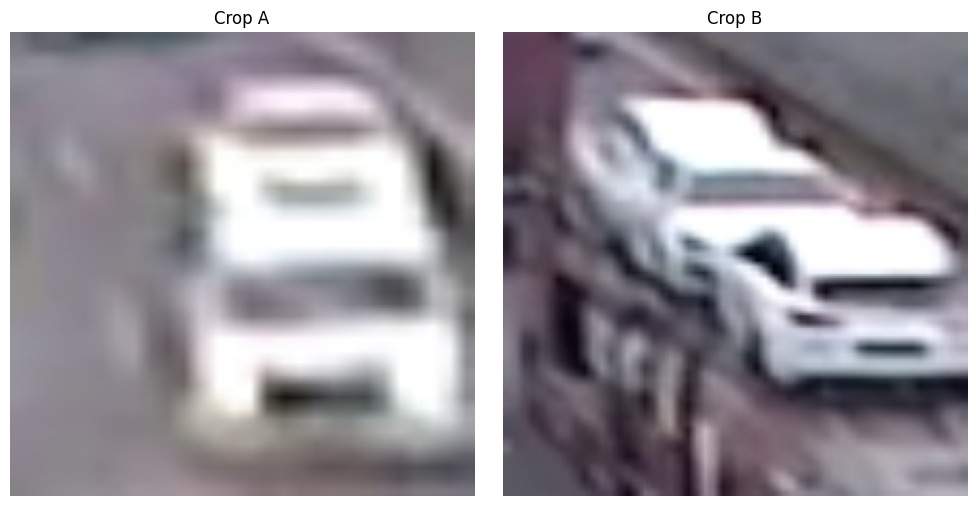

In [7]:
index = int(40684 / 2)

(path_a, id_a), (path_b, id_b) = pairs[index]
track_a_crops = get_crops_for_id(path_a, id_a)
track_b_crops = get_crops_for_id(path_b, id_b)

print("Number of crops for A:", len(track_a_crops))
print("Number of crops for B:", len(track_b_crops))
print("Similarity scores:", scores[index])

track_a_crops = [track_a_crops[0], track_a_crops[-1]] if len(track_a_crops) > 1 else track_a_crops
track_b_crops = [track_b_crops[0], track_b_crops[-1]] if len(track_b_crops) > 1 else track_b_crops

for crop_a, crop_b in zip(track_a_crops, track_b_crops):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cv2.cvtColor(crop_a, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Crop A')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(crop_b, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Crop B')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()